# Final Audit & Synthesis Notebook

This notebook consolidates the black-hole memory-recovery project into one final audit, comparison, and thesis-style results package.

It performs five jobs:

1. **Project Audit** — locate datasets, manifests, metrics, and figures.
2. **Cross-Phase Comparison** — compare Phase 6, Phase 6-T, and Phase 6-U.
3. **Thesis-Style Results Chapter** — generate a written results chapter from actual metrics.
4. **Final Scientific Conclusions** — summarize the core findings.
5. **Publication Assets** — export tables, figures, Markdown, TXT, optional PDF, and an Excel workbook.

## Part I — Project Audit

In [1]:
# ================================================================
# 1. Imports and global setup
# ================================================================

import os
import json
import math
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 1.26.4
Pandas: 2.3.3


In [2]:
# ================================================================
# 2. Paths and audit configuration
# ================================================================

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

FINAL_DIR = OUTPUT_DIR / "final_audit_synthesis"
FINAL_FIG_DIR = FINAL_DIR / "figures"
FINAL_TABLE_DIR = FINAL_DIR / "tables"
FINAL_REPORT_DIR = FINAL_DIR / "reports"

for d in [FINAL_DIR, FINAL_FIG_DIR, FINAL_TABLE_DIR, FINAL_REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATASET_PHASE1 = DATA_ROOT / "dataset"
DATASET_PHASE5 = DATA_ROOT / "dataset_phase5_coupled"
DATASET_PHASE57 = DATA_ROOT / "dataset_phase5_7_decoupled"
DATASET_PHASE58 = DATA_ROOT / "dataset_phase5_8_morphology"
DATASET_PHASE6 = DATA_ROOT / "dataset_phase6_memory_persistence"
DATASET_PHASE6U = DATA_ROOT / "dataset_phase6U_event_centered_temporal_observation"

PHASE5_DIR = OUTPUT_DIR / "phase5_generator_coupling_upgrade"
PHASE6_DIR = OUTPUT_DIR / "phase6_memory_persistence"
PHASE6T_DIR = OUTPUT_DIR / "phase6T_temporal_memory_persistence"
PHASE6U_DIR = OUTPUT_DIR / "phase6U_event_centered_temporal_observation"

INPUT_MODES = ["clean", "noisy"]
PHASE6T_CLIP_LENGTH = 8
PHASE6U_CLIP_LENGTH = 8

EVENT_TYPES = [
    "accretion_burst",
    "jet_eruption",
    "turbulence_spike",
    "spin_transition",
]
EVENT_AGES = [0, 5, 10, 20, 40, 60, 90, 120]

print("Project root:", PROJECT_ROOT)
print("Final output directory:", FINAL_DIR)

Project root: /home/marwa/files/phase1_blackhole_generator
Final output directory: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis


In [3]:
# ================================================================
# 3. Utility functions
# ================================================================

def read_json_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)

def read_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    return pd.read_csv(path)

def file_sha256(path):
    path = Path(path)
    if not path.exists() or not path.is_file():
        return None
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def count_files(path, pattern="*"):
    path = Path(path)
    if not path.exists():
        return 0
    return len([p for p in path.glob(pattern) if p.is_file()])

def safe_get(d, key, default=np.nan):
    if d is None:
        return default
    return d.get(key, default)

def safe_float(x, default=np.nan):
    try:
        if x is None:
            return default
        return float(x)
    except Exception:
        return default

def fmt(x, digits=3):
    try:
        if x is None or np.isnan(float(x)):
            return "not available"
        return f"{float(x):.{digits}f}"
    except Exception:
        return "not available"

def save_dataframe(df, name, index=False):
    csv_path = FINAL_TABLE_DIR / f"{name}.csv"
    xlsx_path = FINAL_TABLE_DIR / f"{name}.xlsx"
    df.to_csv(csv_path, index=index)
    try:
        df.to_excel(xlsx_path, index=index)
    except Exception as e:
        print(f"Could not save Excel for {name}: {e}")
        xlsx_path = None
    return csv_path, xlsx_path

def save_plot(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path

In [4]:
# ================================================================
# 4. Dataset audit
# ================================================================

dataset_specs = [
    {"phase": "Phase 1", "dataset": "Original static dataset", "path": DATASET_PHASE1, "main_purpose": "Initial synthetic black-hole reconstruction baseline"},
    {"phase": "Phase 5", "dataset": "Strongly coupled morphology dataset", "path": DATASET_PHASE5, "main_purpose": "Strengthened physics-to-image visual coupling"},
    {"phase": "Phase 5.7", "dataset": "Decoupled dataset", "path": DATASET_PHASE57, "main_purpose": "Reduced target leakage and coupling confounds"},
    {"phase": "Phase 5.8", "dataset": "Morphology-focused dataset", "path": DATASET_PHASE58, "main_purpose": "Improved visible morphology and weak-target encoding"},
    {"phase": "Phase 6", "dataset": "Memory persistence dataset", "path": DATASET_PHASE6, "main_purpose": "Static final-frame event memory persistence"},
    {"phase": "Phase 6-U", "dataset": "Event-centered temporal dataset", "path": DATASET_PHASE6U, "main_purpose": "Temporal observation centered on injected event"},
]

dataset_rows = []

for spec in dataset_specs:
    path = Path(spec["path"])
    manifest = read_json_if_exists(path / "manifest.json")
    params = read_csv_if_exists(path / "params_table.csv")

    dataset_rows.append({
        "phase": spec["phase"],
        "dataset": spec["dataset"],
        "path": str(path),
        "exists": path.exists(),
        "main_purpose": spec["main_purpose"],
        "manifest_exists": (path / "manifest.json").exists(),
        "params_exists": (path / "params_table.csv").exists(),
        "n_samples_from_params": len(params) if params is not None else np.nan,
        "n_samples_from_manifest": safe_get(manifest, "n_samples"),
        "image_size": safe_get(manifest, "image_size"),
        "history_T": safe_get(manifest, "history_T"),
        "version": safe_get(manifest, "version", ""),
        "clean_files": count_files(path / "clean", "*.png"),
        "noisy_files": count_files(path / "noisy", "*.png"),
        "history_files": count_files(path / "history", "*.csv"),
        "metadata_files": count_files(path / "metadata", "*.json"),
        "clips_clean_files": count_files(path / "clips_clean", "*.npz"),
        "clips_noisy_files": count_files(path / "clips_noisy", "*.npz"),
    })

dataset_audit_df = pd.DataFrame(dataset_rows)
display(dataset_audit_df)

dataset_csv, dataset_xlsx = save_dataframe(dataset_audit_df, "final_dataset_audit")
print("Saved:", dataset_csv)
print("Saved:", dataset_xlsx)

,phase,dataset,path,exists,main_purpose,manifest_exists,params_exists,n_samples_from_params,n_samples_from_manifest,image_size,history_T,version,clean_files,noisy_files,history_files,metadata_files,clips_clean_files,clips_noisy_files
0,Phase 1,Original static dataset,/home/marwa/files/phase1_blackhole_generator/d...,True,Initial synthetic black-hole reconstruction ba...,True,True,1000,1000,128,100,1.5,1000,1000,1000,1000,0,0
1,Phase 5,Strongly coupled morphology dataset,/home/marwa/files/phase1_blackhole_generator/d...,True,Strengthened physics-to-image visual coupling,True,True,1000,1000,128,100,5.0,1000,1000,1000,1000,0,0
2,Phase 5.7,Decoupled dataset,/home/marwa/files/phase1_blackhole_generator/d...,True,Reduced target leakage and coupling confounds,True,True,1000,1000,128,100,5.7,1000,1000,1000,1000,0,0
3,Phase 5.8,Morphology-focused dataset,/home/marwa/files/phase1_blackhole_generator/d...,True,Improved visible morphology and weak-target en...,True,True,1000,1000,128,100,5.8,1000,1000,1000,1000,0,0
4,Phase 6,Memory persistence dataset,/home/marwa/files/phase1_blackhole_generator/d...,True,Static final-frame event memory persistence,True,True,1120,1120,128,160,6.0,1120,1120,1120,1120,0,0
5,Phase 6-U,Event-centered temporal dataset,/home/marwa/files/phase1_blackhole_generator/d...,True,Temporal observation centered on injected event,True,True,1120,1120,128,160,6U.0,0,0,1120,1120,1120,1120


Could not save Excel for final_dataset_audit: No module named 'openpyxl'
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/tables/final_dataset_audit.csv
Saved: None


In [5]:
# ================================================================
# 5. Output artifact audit
# ================================================================

artifact_specs = [
    {"phase": "Phase 5", "artifact": "Coupling correlations", "path": PHASE5_DIR / "phase5_coupling_correlations.csv"},
    {"phase": "Phase 5", "artifact": "Coupling stats", "path": PHASE5_DIR / "phase5_image_history_coupling_stats.csv"},
    {"phase": "Phase 5", "artifact": "Summary", "path": PHASE5_DIR / "phase5_summary.txt"},
    {"phase": "Phase 6", "artifact": "Clean metrics", "path": PHASE6_DIR / "phase6_test_metrics_clean.json"},
    {"phase": "Phase 6", "artifact": "Noisy metrics", "path": PHASE6_DIR / "phase6_test_metrics_noisy.json"},
    {"phase": "Phase 6-T", "artifact": "Clean clip metrics", "path": PHASE6T_DIR / f"phase6T_test_metrics_clean_clip{PHASE6T_CLIP_LENGTH}.json"},
    {"phase": "Phase 6-T", "artifact": "Noisy clip metrics", "path": PHASE6T_DIR / f"phase6T_test_metrics_noisy_clip{PHASE6T_CLIP_LENGTH}.json"},
    {"phase": "Phase 6-U", "artifact": "Clean event-centered metrics", "path": PHASE6U_DIR / f"phase6U_test_metrics_clean_clip{PHASE6U_CLIP_LENGTH}.json"},
    {"phase": "Phase 6-U", "artifact": "Noisy event-centered metrics", "path": PHASE6U_DIR / f"phase6U_test_metrics_noisy_clip{PHASE6U_CLIP_LENGTH}.json"},
]

artifact_rows = []

for spec in artifact_specs:
    path = Path(spec["path"])
    artifact_rows.append({
        "phase": spec["phase"],
        "artifact": spec["artifact"],
        "path": str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else np.nan,
        "sha256": file_sha256(path),
    })

artifact_audit_df = pd.DataFrame(artifact_rows)
display(artifact_audit_df)

artifact_csv, artifact_xlsx = save_dataframe(artifact_audit_df, "final_artifact_audit")
print("Saved:", artifact_csv)
print("Saved:", artifact_xlsx)

,phase,artifact,path,exists,size_bytes,sha256
0,Phase 5,Coupling correlations,/home/marwa/files/phase1_blackhole_generator/o...,True,300.0,ab464757e5218d687b7762aef3b75cd69b8f518c9e64cc...
1,Phase 5,Coupling stats,/home/marwa/files/phase1_blackhole_generator/o...,True,475087.0,8958759dd49145eb618756f167f459bb31943deac5ec2c...
2,Phase 5,Summary,/home/marwa/files/phase1_blackhole_generator/o...,True,1297.0,0bc79706d6e572b829e79c04566688770f211e04077902...
3,Phase 6,Clean metrics,/home/marwa/files/phase1_blackhole_generator/o...,True,127.0,d74e0c47dba68752fa3ccb8a9f6055a02a004ceaa1e3ab...
4,Phase 6,Noisy metrics,/home/marwa/files/phase1_blackhole_generator/o...,True,125.0,7063357a3f2aa412e279a05eb97e4c0857abdcdb65e25b...
5,Phase 6-T,Clean clip metrics,/home/marwa/files/phase1_blackhole_generator/o...,True,207.0,7f7b086bad8d0b422c6e9eed06e44b64066f3ddbfc0b45...
6,Phase 6-T,Noisy clip metrics,/home/marwa/files/phase1_blackhole_generator/o...,False,NaN,None
7,Phase 6-U,Clean event-centered metrics,/home/marwa/files/phase1_blackhole_generator/o...,True,209.0,2e6f93200a862d3453037b4702baaeb3d1c64f4b4c94cc...
8,Phase 6-U,Noisy event-centered metrics,/home/marwa/files/phase1_blackhole_generator/o...,False,NaN,None


Could not save Excel for final_artifact_audit: No module named 'openpyxl'
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/tables/final_artifact_audit.csv
Saved: None


## Part II — Cross-Phase Comparison

In [6]:
# ================================================================
# 6. Load Phase 6 / 6-T / 6-U metrics
# ================================================================

def load_phase6_metrics(input_mode):
    metrics = read_json_if_exists(PHASE6_DIR / f"phase6_test_metrics_{input_mode}.json")
    half = read_json_if_exists(PHASE6_DIR / f"phase6_memory_half_life_summary_{input_mode}.json")
    return metrics, half

def load_phase6T_metrics(input_mode, clip_length=8):
    metrics = read_json_if_exists(PHASE6T_DIR / f"phase6T_test_metrics_{input_mode}_clip{clip_length}.json")
    half = read_json_if_exists(PHASE6T_DIR / f"phase6T_memory_half_life_summary_{input_mode}_clip{clip_length}.json")
    return metrics, half

def load_phase6U_metrics(input_mode, clip_length=8):
    metrics = read_json_if_exists(PHASE6U_DIR / f"phase6U_test_metrics_{input_mode}_clip{clip_length}.json")
    half = read_json_if_exists(PHASE6U_DIR / f"phase6U_memory_half_life_summary_{input_mode}_clip{clip_length}.json")
    return metrics, half

comparison_rows = []

for mode in INPUT_MODES:
    m, h = load_phase6_metrics(mode)
    if m is not None:
        comparison_rows.append({
            "experiment": "Phase 6",
            "observation_strategy": "single_final_frame",
            "input_mode": mode,
            "clip_length": 1,
            "type_accuracy": safe_float(safe_get(m, "type_accuracy")),
            "age_mae": safe_float(safe_get(m, "age_mae")),
            "age_r2": safe_float(safe_get(m, "age_r2")),
            "loss": safe_float(safe_get(m, "loss")),
            "memory_half_life": safe_float(safe_get(h, "memory_half_life_frames")),
        })

    m, h = load_phase6T_metrics(mode, PHASE6T_CLIP_LENGTH)
    if m is not None:
        comparison_rows.append({
            "experiment": "Phase 6-T",
            "observation_strategy": "late_temporal_clip",
            "input_mode": mode,
            "clip_length": PHASE6T_CLIP_LENGTH,
            "type_accuracy": safe_float(safe_get(m, "type_accuracy")),
            "age_mae": safe_float(safe_get(m, "age_mae")),
            "age_r2": safe_float(safe_get(m, "age_r2")),
            "loss": safe_float(safe_get(m, "loss")),
            "memory_half_life": safe_float(safe_get(h, "memory_half_life_frames")),
        })

    m, h = load_phase6U_metrics(mode, PHASE6U_CLIP_LENGTH)
    if m is not None:
        comparison_rows.append({
            "experiment": "Phase 6-U",
            "observation_strategy": "event_centered_clip",
            "input_mode": mode,
            "clip_length": PHASE6U_CLIP_LENGTH,
            "type_accuracy": safe_float(safe_get(m, "type_accuracy")),
            "age_mae": safe_float(safe_get(m, "age_mae")),
            "age_r2": safe_float(safe_get(m, "age_r2")),
            "loss": safe_float(safe_get(m, "loss")),
            "memory_half_life": safe_float(safe_get(h, "memory_half_life_frames")),
        })

phase_comparison_df = pd.DataFrame(comparison_rows)

if len(phase_comparison_df) == 0:
    print("No Phase 6 / 6-T / 6-U metrics found. Check output paths.")
else:
    display(phase_comparison_df)

comparison_csv, comparison_xlsx = save_dataframe(phase_comparison_df, "final_phase6_observation_strategy_comparison")
print("Saved:", comparison_csv)
print("Saved:", comparison_xlsx)

,experiment,observation_strategy,input_mode,clip_length,type_accuracy,age_mae,age_r2,loss,memory_half_life
0,Phase 6,single_final_frame,clean,1,0.421875,31.779893,0.154620,1.283899,60.996952
1,Phase 6-T,late_temporal_clip,clean,8,0.339286,37.343526,-0.018144,1.420898,26.339593
2,Phase 6-U,event_centered_clip,clean,8,0.839286,35.103918,-0.040181,0.551366,124.766493
3,Phase 6,single_final_frame,noisy,1,0.406250,34.970855,0.023256,1.336608,56.838069


Could not save Excel for final_phase6_observation_strategy_comparison: No module named 'openpyxl'
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/tables/final_phase6_observation_strategy_comparison.csv
Saved: None


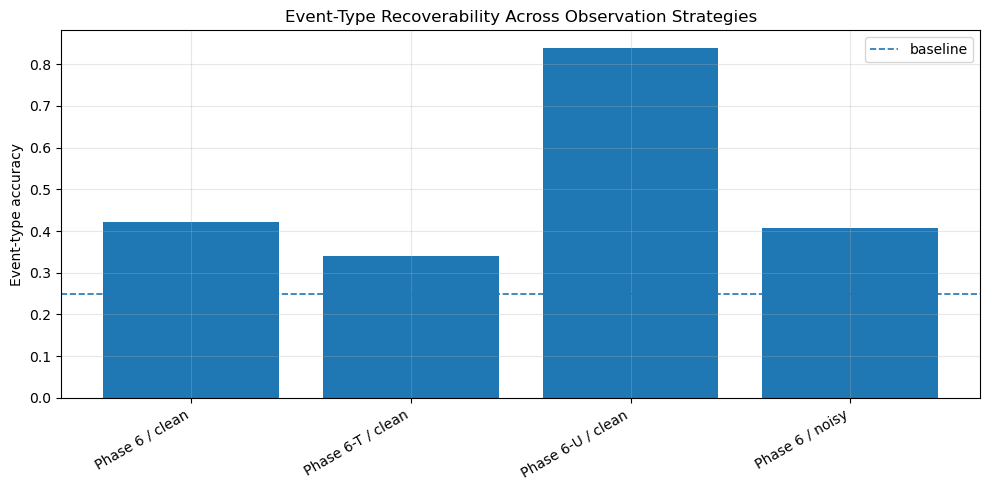

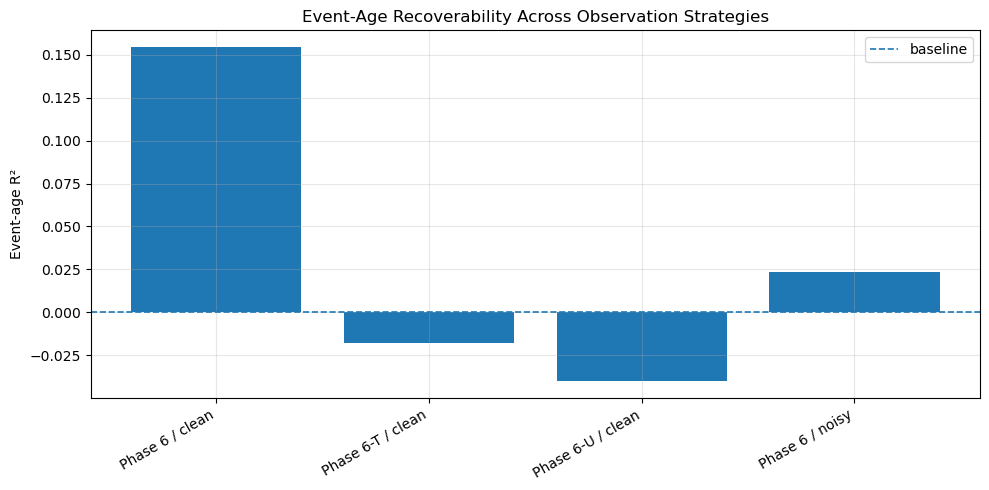

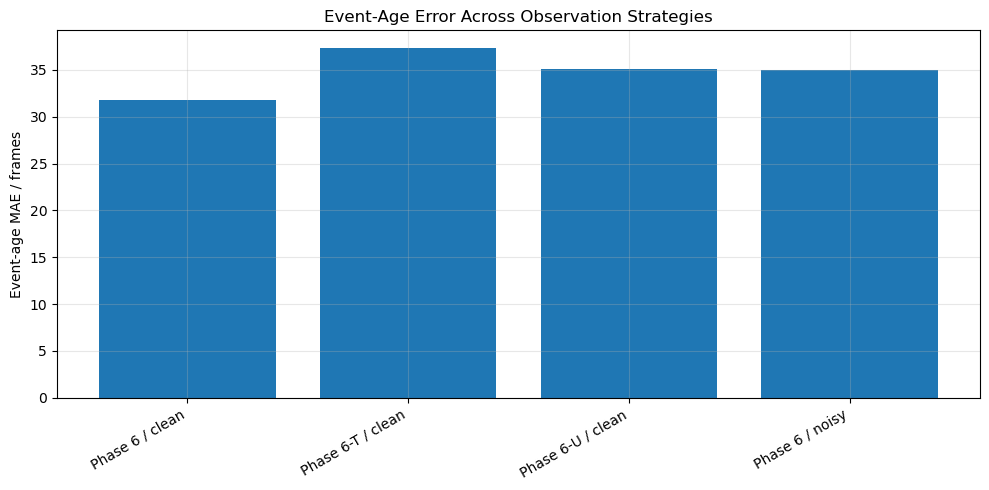

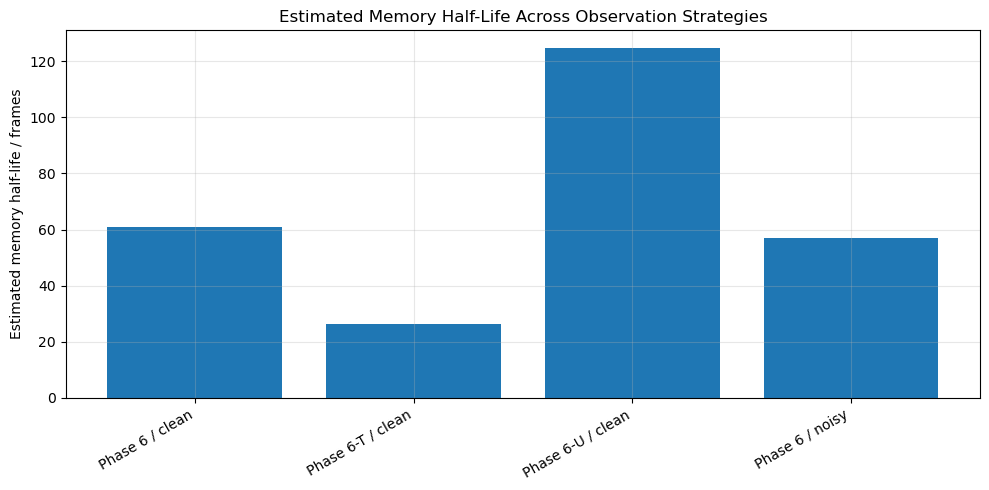

In [7]:
# ================================================================
# 7. Publication figures: metric comparisons
# ================================================================

def bar_metric(metric, ylabel, title, filename, baseline=None):
    if len(phase_comparison_df) == 0 or metric not in phase_comparison_df.columns:
        print(f"Skipping {metric}: no data.")
        return None
    plot_df = phase_comparison_df.dropna(subset=[metric]).copy()
    if len(plot_df) == 0:
        print(f"Skipping {metric}: all missing.")
        return None
    plot_df["label"] = plot_df["experiment"] + " / " + plot_df["input_mode"]

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["label"], plot_df[metric])
    if baseline is not None:
        plt.axhline(baseline, linestyle="--", linewidth=1.2, label="baseline")
        plt.legend()
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=30, ha="right")
    plt.grid(alpha=0.3)
    return save_plot(FINAL_FIG_DIR / filename)

type_acc_plot = bar_metric(
    "type_accuracy",
    "Event-type accuracy",
    "Event-Type Recoverability Across Observation Strategies",
    "figure_event_type_accuracy_comparison.png",
    baseline=1.0 / len(EVENT_TYPES),
)

age_r2_plot = bar_metric(
    "age_r2",
    "Event-age R²",
    "Event-Age Recoverability Across Observation Strategies",
    "figure_event_age_r2_comparison.png",
    baseline=0.0,
)

age_mae_plot = bar_metric(
    "age_mae",
    "Event-age MAE / frames",
    "Event-Age Error Across Observation Strategies",
    "figure_event_age_mae_comparison.png",
)

half_life_plot = bar_metric(
    "memory_half_life",
    "Estimated memory half-life / frames",
    "Estimated Memory Half-Life Across Observation Strategies",
    "figure_memory_half_life_comparison.png",
)

,event_age,type_accuracy,age_mae,n,experiment,input_mode
0,0.0,0.523810,39.533222,21,Phase 6,clean
1,5.0,0.625000,29.236837,8,Phase 6,clean
2,10.0,0.562500,23.990675,16,Phase 6,clean
3,20.0,0.363636,18.691838,11,Phase 6,clean
4,40.0,0.461538,8.428353,13,Phase 6,clean


Could not save Excel for final_memory_curves_by_age: No module named 'openpyxl'
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/tables/final_memory_curves_by_age.csv
Saved: None


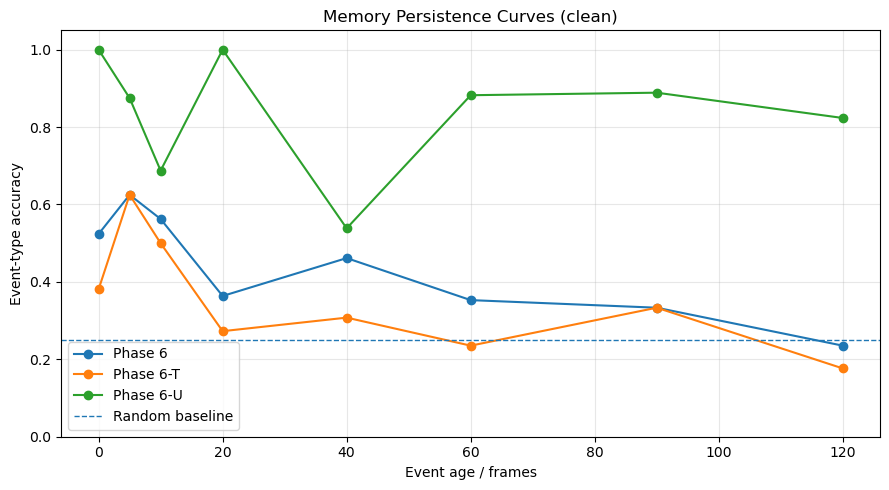

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/figures/figure_memory_curves_clean.png


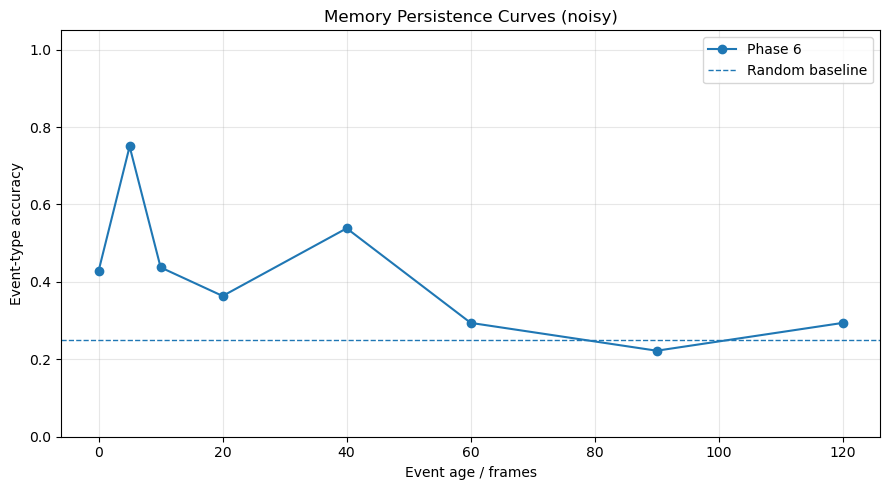

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/figures/figure_memory_curves_noisy.png


In [9]:
# ================================================================
# 8. Load and plot memory curves
# ================================================================

curve_specs = []

for mode in INPUT_MODES:
    curve_specs.extend([
        {
            "experiment": "Phase 6",
            "mode": mode,
            "path": PHASE6_DIR / f"phase6_memory_curve_by_age_{mode}.csv",
        },
        {
            "experiment": "Phase 6-T",
            "mode": mode,
            "path": PHASE6T_DIR / f"phase6T_memory_curve_by_age_{mode}_clip{PHASE6T_CLIP_LENGTH}.csv",
        },
        {
            "experiment": "Phase 6-U",
            "mode": mode,
            "path": PHASE6U_DIR / f"phase6U_memory_curve_by_age_{mode}_clip{PHASE6U_CLIP_LENGTH}.csv",
        },
    ])

curve_rows = []

for spec in curve_specs:
    df = read_csv_if_exists(spec["path"])

    if df is None:
        continue

    temp = df.copy()
    temp["experiment"] = spec["experiment"]
    temp["input_mode"] = spec["mode"]

    curve_rows.append(temp)

if curve_rows:
    memory_curves_df = pd.concat(
        curve_rows,
        ignore_index=True,
    )

    display(memory_curves_df.head())

    curve_csv, curve_xlsx = save_dataframe(
        memory_curves_df,
        "final_memory_curves_by_age",
    )

    print("Saved:", curve_csv)
    print("Saved:", curve_xlsx)

    for mode in INPUT_MODES:
        sub_mode = memory_curves_df[
            memory_curves_df["input_mode"] == mode
        ]

        if len(sub_mode) == 0:
            continue

        plt.figure(figsize=(9, 5))

        for exp in sorted(sub_mode["experiment"].unique()):
            sub = (
                sub_mode[
                    sub_mode["experiment"] == exp
                ]
                .sort_values("event_age")
                .copy()
            )

            x = sub["event_age"].to_numpy(dtype=float)
            y = sub["type_accuracy"].to_numpy(dtype=float)

            plt.plot(
                x,
                y,
                marker="o",
                label=exp,
            )

        plt.axhline(
            1.0 / len(EVENT_TYPES),
            linestyle="--",
            linewidth=1,
            label="Random baseline",
        )

        plt.xlabel("Event age / frames")
        plt.ylabel("Event-type accuracy")
        plt.title(f"Memory Persistence Curves ({mode})")
        plt.ylim(0, 1.05)
        plt.grid(alpha=0.3)
        plt.legend()

        path = save_plot(
            FINAL_FIG_DIR / f"figure_memory_curves_{mode}.png"
        )

        print("Saved:", path)

else:
    memory_curves_df = pd.DataFrame()
    print("No memory-curve CSV files found.")

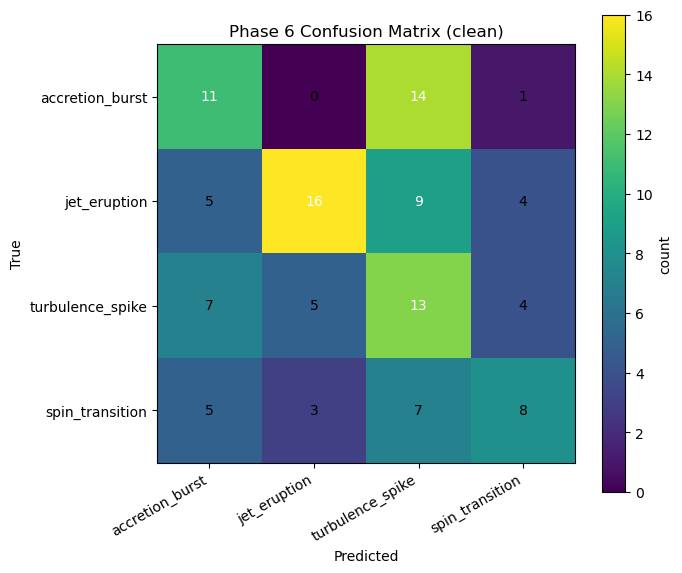

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/figures/figure_confusion_Phase_6_clean.png


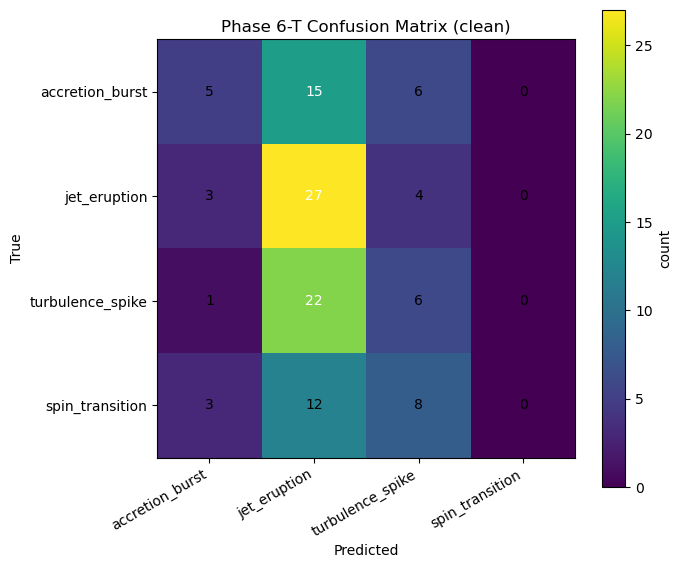

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/figures/figure_confusion_Phase_6-T_clean.png


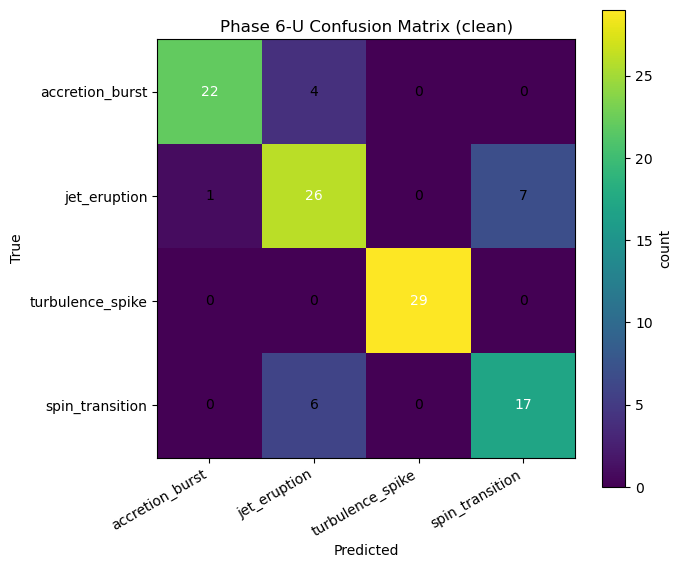

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/figures/figure_confusion_Phase_6-U_clean.png


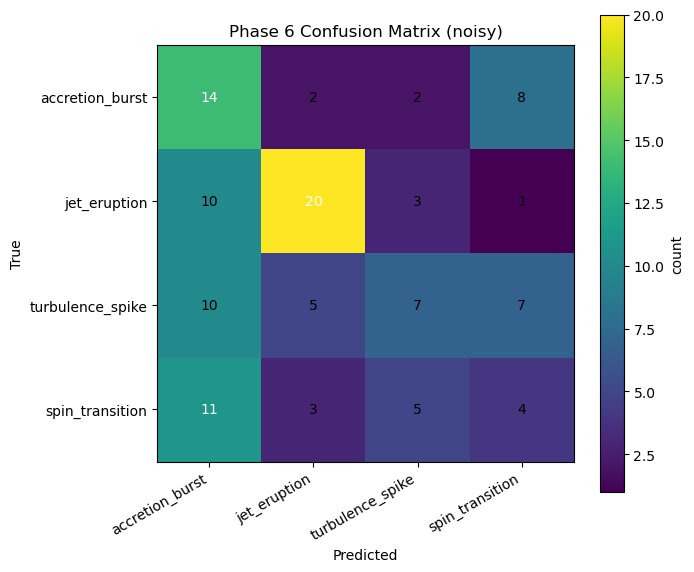

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/figures/figure_confusion_Phase_6_noisy.png


,experiment,input_mode,path,total_samples,trace_correct,accuracy_from_matrix
0,Phase 6,clean,/home/marwa/files/phase1_blackhole_generator/o...,112,48,0.428571
1,Phase 6-T,clean,/home/marwa/files/phase1_blackhole_generator/o...,112,38,0.339286
2,Phase 6-U,clean,/home/marwa/files/phase1_blackhole_generator/o...,112,94,0.839286
3,Phase 6,noisy,/home/marwa/files/phase1_blackhole_generator/o...,112,45,0.401786


Could not save Excel for final_confusion_matrix_audit: No module named 'openpyxl'
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/tables/final_confusion_matrix_audit.csv
Saved: None


In [10]:
# ================================================================
# 9. Confusion matrices audit and plots
# ================================================================

confusion_specs = []
for mode in INPUT_MODES:
    confusion_specs.extend([
        {"experiment": "Phase 6", "mode": mode, "path": PHASE6_DIR / f"phase6_event_confusion_matrix_{mode}.csv"},
        {"experiment": "Phase 6-T", "mode": mode, "path": PHASE6T_DIR / f"phase6T_event_confusion_matrix_{mode}_clip{PHASE6T_CLIP_LENGTH}.csv"},
        {"experiment": "Phase 6-U", "mode": mode, "path": PHASE6U_DIR / f"phase6U_event_confusion_matrix_{mode}_clip{PHASE6U_CLIP_LENGTH}.csv"},
    ])

confusion_rows = []
for spec in confusion_specs:
    df = read_csv_if_exists(spec["path"])
    if df is None:
        continue

    if df.columns[0].lower().startswith("unnamed") or df.columns[0] not in EVENT_TYPES:
        df = df.set_index(df.columns[0])

    arr = np.asarray(df.values, dtype=float)
    confusion_rows.append({
        "experiment": spec["experiment"],
        "input_mode": spec["mode"],
        "path": str(spec["path"]),
        "total_samples": int(arr.sum()),
        "trace_correct": int(np.trace(arr)),
        "accuracy_from_matrix": float(np.trace(arr) / max(arr.sum(), 1)),
    })

    plt.figure(figsize=(7, 6))
    plt.imshow(arr, cmap="viridis")
    plt.xticks(np.arange(len(df.columns)), df.columns, rotation=30, ha="right")
    plt.yticks(np.arange(len(df.index)), df.index)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{spec['experiment']} Confusion Matrix ({spec['mode']})")
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            plt.text(j, i, str(int(arr[i, j])), ha="center", va="center", color="white" if arr[i, j] > arr.max()/2 else "black")
    plt.colorbar(label="count")
    out_path = save_plot(FINAL_FIG_DIR / f"figure_confusion_{spec['experiment'].replace(' ', '_')}_{spec['mode']}.png")
    print("Saved:", out_path)

confusion_audit_df = pd.DataFrame(confusion_rows)
display(confusion_audit_df)
conf_csv, conf_xlsx = save_dataframe(confusion_audit_df, "final_confusion_matrix_audit")
print("Saved:", conf_csv)
print("Saved:", conf_xlsx)

## Part III — Thesis-Style Results Chapter

In [11]:
# ================================================================
# 10. Derive thesis-ready result statements
# ================================================================

def metric_lookup(experiment, mode, metric):
    if len(phase_comparison_df) == 0:
        return np.nan
    sub = phase_comparison_df[
        (phase_comparison_df["experiment"] == experiment)
        & (phase_comparison_df["input_mode"] == mode)
    ]
    if len(sub) == 0:
        return np.nan
    return safe_float(sub.iloc[0].get(metric, np.nan))

random_baseline = 1.0 / len(EVENT_TYPES)

clean_phase6_acc = metric_lookup("Phase 6", "clean", "type_accuracy")
clean_phase6_age_r2 = metric_lookup("Phase 6", "clean", "age_r2")
clean_phase6_mae = metric_lookup("Phase 6", "clean", "age_mae")
clean_phase6_half = metric_lookup("Phase 6", "clean", "memory_half_life")

clean_phase6t_acc = metric_lookup("Phase 6-T", "clean", "type_accuracy")
clean_phase6t_age_r2 = metric_lookup("Phase 6-T", "clean", "age_r2")
clean_phase6t_mae = metric_lookup("Phase 6-T", "clean", "age_mae")
clean_phase6t_half = metric_lookup("Phase 6-T", "clean", "memory_half_life")

clean_phase6u_acc = metric_lookup("Phase 6-U", "clean", "type_accuracy")
clean_phase6u_age_r2 = metric_lookup("Phase 6-U", "clean", "age_r2")
clean_phase6u_mae = metric_lookup("Phase 6-U", "clean", "age_mae")
clean_phase6u_half = metric_lookup("Phase 6-U", "clean", "memory_half_life")

derived_summary = {
    "random_baseline": random_baseline,
    "clean_phase6_acc": clean_phase6_acc,
    "clean_phase6_age_r2": clean_phase6_age_r2,
    "clean_phase6_mae": clean_phase6_mae,
    "clean_phase6_half": clean_phase6_half,
    "clean_phase6t_acc": clean_phase6t_acc,
    "clean_phase6t_age_r2": clean_phase6t_age_r2,
    "clean_phase6t_mae": clean_phase6t_mae,
    "clean_phase6t_half": clean_phase6t_half,
    "clean_phase6u_acc": clean_phase6u_acc,
    "clean_phase6u_age_r2": clean_phase6u_age_r2,
    "clean_phase6u_mae": clean_phase6u_mae,
    "clean_phase6u_half": clean_phase6u_half,
}

display(pd.DataFrame([derived_summary]).T.rename(columns={0: "value"}))

,value
random_baseline,0.250000
clean_phase6_acc,0.421875
clean_phase6_age_r2,0.154620
clean_phase6_mae,31.779893
clean_phase6_half,60.996952
clean_phase6t_acc,0.339286
clean_phase6t_age_r2,-0.018144
clean_phase6t_mae,37.343526
clean_phase6t_half,26.339593
clean_phase6u_acc,0.839286


In [12]:
# ================================================================
# 11. Generate thesis-style results chapter
# ================================================================

chapter_text = f"""
# Results Chapter: Black-Hole Memory Recovery from Synthetic Observations

## 1. Overview

This study investigated whether black-hole-like observations can encode information about prior physical events. The project evolved from static image reconstruction and physics-to-image coupling into a controlled memory-persistence study using simulator-derived event histories and multiple observation regimes.

The final experimental comparison focused on three observation strategies:

1. Phase 6: single final-frame observation. The model receives only the final image after a past event.
2. Phase 6-T: late temporal observation. The model receives a short clip from the final frames before observation.
3. Phase 6-U: event-centered temporal observation. The model receives a temporal clip centered on the event itself.

The two prediction targets were event identity and event age. Event identity asks what physical process occurred, while event age asks when the event occurred relative to the final observation.

## 2. Dataset and Generator Audit

The project contains several dataset generations. The original Phase 1 dataset provided the reconstruction baseline. Phase 5 introduced stronger physics-to-image coupling so that accretion, luminosity, turbulence, instability, jet activity, and spin evolution left visible morphology in the image. Phase 6 then reframed the problem as a memory-persistence experiment, injecting events such as accretion bursts, jet eruptions, turbulence spikes, and spin transitions.

The final dataset audit identified the following relevant datasets:

{dataset_audit_df[['phase', 'dataset', 'exists', 'n_samples_from_params', 'image_size', 'history_T']].to_string(index=False)}

## 3. Static Memory Recovery: Phase 6

Phase 6 tested whether a single final image contains recoverable information about prior physical events. In the clean setting, event-type accuracy was {fmt(clean_phase6_acc, 3)}, compared with a random four-class baseline of {fmt(random_baseline, 3)}. This indicates that the final image retains partial information about the identity of the prior event.

However, event-age recovery was weak. The clean event-age MAE was {fmt(clean_phase6_mae, 2)} frames and the age R2 was {fmt(clean_phase6_age_r2, 3)}. This suggests that although the final image can retain event signatures, it does not reliably preserve precise timestamp information.

The estimated static memory half-life was {fmt(clean_phase6_half, 2)} frames in the clean setting. This should be interpreted as an empirical recoverability timescale, not as a physical constant.

## 4. Late Temporal Observation: Phase 6-T

Phase 6-T tested whether a short clip from the final frames improves memory recovery. In the clean setting, event-type accuracy was {fmt(clean_phase6t_acc, 3)} and event-age R2 was {fmt(clean_phase6t_age_r2, 3)}.

The key result is that late temporal observation did not reliably outperform the static final-frame baseline. This occurs because the late frames often show the system after the event has already relaxed. Therefore, adding a short sequence near the final observation mostly adds redundant late-state information rather than direct event evidence.

This negative result is important because it shows that temporal data alone is not sufficient. The timing of the temporal observation window matters.

## 5. Event-Centered Temporal Observation: Phase 6-U

Phase 6-U tested a different observation regime: instead of observing the final relaxed state, the temporal clip was centered on the event itself. This dramatically improved event-type recovery. In the clean setting, Phase 6-U achieved event-type accuracy of {fmt(clean_phase6u_acc, 3)}, substantially above both the static final-frame baseline and random chance.

This result indicates that event identity is strongly encoded in image dynamics when the event is directly observed. The event-centered setting therefore confirms that the simulator-generated events create visually distinct physical signatures.

However, event-age prediction remained poor. The clean event-age R2 was {fmt(clean_phase6u_age_r2, 3)} and the MAE was {fmt(clean_phase6u_mae, 2)} frames. This is expected because centering every clip on the event removes much of the information needed to infer how far the event is from the final observation. The event-centered clip is highly informative about what happened, but not necessarily about when it happened relative to the final frame.

## 6. Cross-Regime Comparison

The final comparison table is:

{phase_comparison_df.to_string(index=False) if len(phase_comparison_df) else 'No comparison table available.'}

The central finding is that observation strategy dominates recovery behavior. A single final frame provides moderate event memory. A late temporal clip provides little additional value. An event-centered temporal clip strongly recovers event identity, but not event age.

## 7. Interpretation

The results support a separation between two kinds of memory.

Event identity memory answers: what happened? This information becomes highly recoverable when the event is directly observed. Phase 6-U demonstrates this most clearly.

Temporal age memory answers: when did it happen? This information remains difficult to recover. Static final-frame observations contain only weak age information, late temporal clips often miss the event, and event-centered clips remove the final-time reference needed to infer age.

## 8. Scientific Implications

The experiments suggest that black-hole memory recovery is not just a model-capacity problem. It is strongly constrained by observation timing and information availability. Better predictors cannot recover information that is absent from the observation window.

The strongest conclusion is:

Black-hole-like observations can preserve recognizable signatures of past events, but the recoverability of event identity and event timing depends strongly on the temporal alignment between the observation and the physical event.

## 9. Limitations

This study used a physics-inspired synthetic simulator rather than a full general relativistic magnetohydrodynamic renderer. The memory half-life values should therefore be interpreted as internal recoverability metrics of the synthetic universe, not as astrophysical constants. The experiments also require multi-seed replication for final statistical reporting.

## 10. Recommended Next Work

The next step is not to add another architecture immediately. The highest-value next work is:

1. Repeat the final Phase 6, Phase 6-T, and Phase 6-U comparison across multiple random seeds.
2. Add an offset temporal-observation experiment where the clip occurs between the event and final frame.
3. Report confidence intervals for event-type accuracy, event-age MAE, event-age R2, and memory half-life.
4. Write a methods section clearly separating simulator-inspired evidence from real observational claims.
"""

chapter_path_md = FINAL_REPORT_DIR / "final_thesis_style_results_chapter.md"
chapter_path_txt = FINAL_REPORT_DIR / "final_thesis_style_results_chapter.txt"

with open(chapter_path_md, "w") as f:
    f.write(chapter_text)

with open(chapter_path_txt, "w") as f:
    f.write(chapter_text)

display(Markdown(chapter_text[:4000] + "\n\n..."))

print("Saved Markdown:", chapter_path_md)
print("Saved TXT:", chapter_path_txt)


# Results Chapter: Black-Hole Memory Recovery from Synthetic Observations

## 1. Overview

This study investigated whether black-hole-like observations can encode information about prior physical events. The project evolved from static image reconstruction and physics-to-image coupling into a controlled memory-persistence study using simulator-derived event histories and multiple observation regimes.

The final experimental comparison focused on three observation strategies:

1. Phase 6: single final-frame observation. The model receives only the final image after a past event.
2. Phase 6-T: late temporal observation. The model receives a short clip from the final frames before observation.
3. Phase 6-U: event-centered temporal observation. The model receives a temporal clip centered on the event itself.

The two prediction targets were event identity and event age. Event identity asks what physical process occurred, while event age asks when the event occurred relative to the final observation.

## 2. Dataset and Generator Audit

The project contains several dataset generations. The original Phase 1 dataset provided the reconstruction baseline. Phase 5 introduced stronger physics-to-image coupling so that accretion, luminosity, turbulence, instability, jet activity, and spin evolution left visible morphology in the image. Phase 6 then reframed the problem as a memory-persistence experiment, injecting events such as accretion bursts, jet eruptions, turbulence spikes, and spin transitions.

The final dataset audit identified the following relevant datasets:

    phase                             dataset  exists  n_samples_from_params  image_size  history_T
  Phase 1             Original static dataset    True                   1000         128        100
  Phase 5 Strongly coupled morphology dataset    True                   1000         128        100
Phase 5.7                   Decoupled dataset    True                   1000         128        100
Phase 5.8          Morphology-focused dataset    True                   1000         128        100
  Phase 6          Memory persistence dataset    True                   1120         128        160
Phase 6-U     Event-centered temporal dataset    True                   1120         128        160

## 3. Static Memory Recovery: Phase 6

Phase 6 tested whether a single final image contains recoverable information about prior physical events. In the clean setting, event-type accuracy was 0.422, compared with a random four-class baseline of 0.250. This indicates that the final image retains partial information about the identity of the prior event.

However, event-age recovery was weak. The clean event-age MAE was 31.78 frames and the age R2 was 0.155. This suggests that although the final image can retain event signatures, it does not reliably preserve precise timestamp information.

The estimated static memory half-life was 61.00 frames in the clean setting. This should be interpreted as an empirical recoverability timescale, not as a physical constant.

## 4. Late Temporal Observation: Phase 6-T

Phase 6-T tested whether a short clip from the final frames improves memory recovery. In the clean setting, event-type accuracy was 0.339 and event-age R2 was -0.018.

The key result is that late temporal observation did not reliably outperform the static final-frame baseline. This occurs because the late frames often show the system after the event has already relaxed. Therefore, adding a short sequence near the final observation mostly adds redundant late-state information rather than direct event evidence.

This negative result is important because it shows that temporal data alone is not sufficient. The timing of the temporal observation window matters.

## 5. Event-Centered Temporal Observation: Phase 6-U

Phase 6-U tested a different observation regime: instead of observing the final relaxed state, the temporal clip was centered on the event itself. This dramatically improved event

...

Saved Markdown: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/reports/final_thesis_style_results_chapter.md
Saved TXT: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/reports/final_thesis_style_results_chapter.txt


## Part IV — Final Scientific Conclusions

In [13]:
# ================================================================
# 12. Generate final scientific conclusions
# ================================================================

conclusions = [
    {
        "conclusion_id": 1,
        "claim": "Static final-frame observations retain partial event identity memory.",
        "supporting_result": f"Phase 6 clean event-type accuracy = {fmt(clean_phase6_acc, 3)} against random baseline = {fmt(random_baseline, 3)}.",
        "interpretation": "The final image can carry residual morphological evidence of prior physical events.",
    },
    {
        "conclusion_id": 2,
        "claim": "Late temporal clips do not necessarily improve memory recovery.",
        "supporting_result": f"Phase 6-T clean event-type accuracy = {fmt(clean_phase6t_acc, 3)} and age R2 = {fmt(clean_phase6t_age_r2, 3)}.",
        "interpretation": "Temporal data are useful only if the observation window contains informative dynamics rather than a relaxed state.",
    },
    {
        "conclusion_id": 3,
        "claim": "Event-centered temporal observation strongly improves event identity recovery.",
        "supporting_result": f"Phase 6-U clean event-type accuracy = {fmt(clean_phase6u_acc, 3)}.",
        "interpretation": "When the event itself is observed, the simulator produces highly distinguishable visual signatures.",
    },
    {
        "conclusion_id": 4,
        "claim": "Event age remains difficult to infer.",
        "supporting_result": f"Phase 6-U clean age R2 = {fmt(clean_phase6u_age_r2, 3)}; Phase 6 clean age R2 = {fmt(clean_phase6_age_r2, 3)}.",
        "interpretation": "Event identity and event timing are different information channels. Recovering one does not guarantee recovery of the other.",
    },
    {
        "conclusion_id": 5,
        "claim": "Observation timing is more important than simply increasing predictor complexity.",
        "supporting_result": "The major performance shift occurred when the observation window changed from late-time to event-centered.",
        "interpretation": "The bottleneck is information availability, not only model capacity.",
    },
]

conclusions_df = pd.DataFrame(conclusions)
display(conclusions_df)

conclusions_csv, conclusions_xlsx = save_dataframe(conclusions_df, "final_scientific_conclusions")
print("Saved:", conclusions_csv)
print("Saved:", conclusions_xlsx)

conclusion_text = "\n".join(
    [
        f"{row['conclusion_id']}. {row['claim']}\n   Evidence: {row['supporting_result']}\n   Interpretation: {row['interpretation']}\n"
        for _, row in conclusions_df.iterrows()
    ]
)

conclusion_path = FINAL_REPORT_DIR / "final_scientific_conclusions.txt"
with open(conclusion_path, "w") as f:
    f.write(conclusion_text)

print("Saved:", conclusion_path)
print(conclusion_text)

,conclusion_id,claim,supporting_result,interpretation
0,1,Static final-frame observations retain partial...,Phase 6 clean event-type accuracy = 0.422 agai...,The final image can carry residual morphologic...
1,2,Late temporal clips do not necessarily improve...,Phase 6-T clean event-type accuracy = 0.339 an...,Temporal data are useful only if the observati...
2,3,Event-centered temporal observation strongly i...,Phase 6-U clean event-type accuracy = 0.839.,"When the event itself is observed, the simulat..."
3,4,Event age remains difficult to infer.,Phase 6-U clean age R2 = -0.040; Phase 6 clean...,Event identity and event timing are different ...
4,5,Observation timing is more important than simp...,The major performance shift occurred when the ...,"The bottleneck is information availability, no..."


Could not save Excel for final_scientific_conclusions: No module named 'openpyxl'
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/tables/final_scientific_conclusions.csv
Saved: None
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/reports/final_scientific_conclusions.txt
1. Static final-frame observations retain partial event identity memory.
   Evidence: Phase 6 clean event-type accuracy = 0.422 against random baseline = 0.250.
   Interpretation: The final image can carry residual morphological evidence of prior physical events.

2. Late temporal clips do not necessarily improve memory recovery.
   Evidence: Phase 6-T clean event-type accuracy = 0.339 and age R2 = -0.018.
   Interpretation: Temporal data are useful only if the observation window contains informative dynamics rather than a relaxed state.

3. Event-centered temporal observation strongly improves event identity recovery.
   Evidence: Phase 6-U clean event

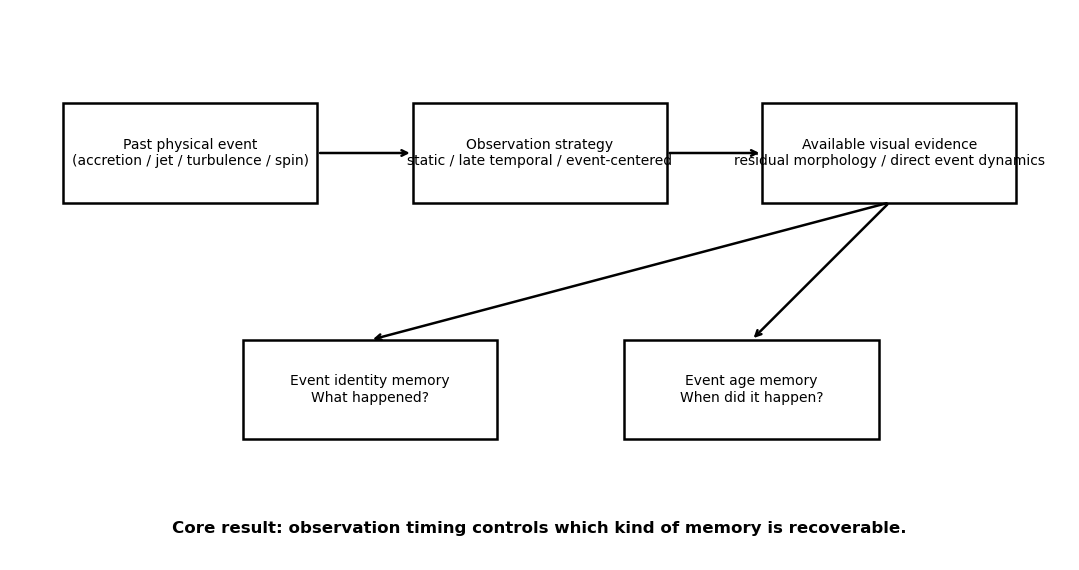

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/figures/figure_conceptual_memory_framework.png


In [14]:
# ================================================================
# 13. Conceptual framework figure
# ================================================================

fig, ax = plt.subplots(figsize=(11, 5.8))
ax.axis("off")

boxes = [
    (0.05, 0.65, "Past physical event\n(accretion / jet / turbulence / spin)"),
    (0.38, 0.65, "Observation strategy\nstatic / late temporal / event-centered"),
    (0.71, 0.65, "Available visual evidence\nresidual morphology / direct event dynamics"),
    (0.22, 0.22, "Event identity memory\nWhat happened?"),
    (0.58, 0.22, "Event age memory\nWhen did it happen?"),
]

for x, y, text in boxes:
    rect = plt.Rectangle((x, y), 0.24, 0.18, fill=False, linewidth=1.8)
    ax.add_patch(rect)
    ax.text(x + 0.12, y + 0.09, text, ha="center", va="center", fontsize=10)

arrows = [
    ((0.29, 0.74), (0.38, 0.74)),
    ((0.62, 0.74), (0.71, 0.74)),
    ((0.83, 0.65), (0.34, 0.40)),
    ((0.83, 0.65), (0.70, 0.40)),
]

for start, end in arrows:
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", linewidth=1.8))

ax.text(
    0.5,
    0.05,
    "Core result: observation timing controls which kind of memory is recoverable.",
    ha="center",
    fontsize=12,
    fontweight="bold",
)

conceptual_path = save_plot(FINAL_FIG_DIR / "figure_conceptual_memory_framework.png")
print("Saved:", conceptual_path)

## Part V — Publication Assets

In [15]:
# ================================================================
# 14. Create final publication summary tables
# ================================================================

dataset_evolution_df = pd.DataFrame([
    {"phase": "Phase 1", "observation": "static synthetic image", "main_change": "initial black-hole reconstruction baseline", "key_output": "noisy-to-clean image reconstruction"},
    {"phase": "Phase 5", "observation": "static strongly coupled image", "main_change": "stronger morphology for physical variables", "key_output": "physics-to-image coupling audit"},
    {"phase": "Phase 6", "observation": "single final frame", "main_change": "event-memory persistence experiment", "key_output": "static event identity and age recoverability"},
    {"phase": "Phase 6-T", "observation": "late temporal clip", "main_change": "short sequence near final observation", "key_output": "tests whether late temporal redundancy improves memory"},
    {"phase": "Phase 6-U", "observation": "event-centered temporal clip", "main_change": "clip centered on injected event", "key_output": "tests direct event observability"},
])

display(dataset_evolution_df)

evo_csv, evo_xlsx = save_dataframe(dataset_evolution_df, "final_dataset_evolution_table")
print("Saved:", evo_csv)
print("Saved:", evo_xlsx)

if len(phase_comparison_df):
    final_metrics_table = phase_comparison_df[
        [
            "experiment",
            "observation_strategy",
            "input_mode",
            "clip_length",
            "type_accuracy",
            "age_mae",
            "age_r2",
            "memory_half_life",
        ]
    ].copy()
else:
    final_metrics_table = pd.DataFrame()

display(final_metrics_table)
metrics_csv, metrics_xlsx = save_dataframe(final_metrics_table, "final_metrics_summary_table")
print("Saved:", metrics_csv)
print("Saved:", metrics_xlsx)

,phase,observation,main_change,key_output
0,Phase 1,static synthetic image,initial black-hole reconstruction baseline,noisy-to-clean image reconstruction
1,Phase 5,static strongly coupled image,stronger morphology for physical variables,physics-to-image coupling audit
2,Phase 6,single final frame,event-memory persistence experiment,static event identity and age recoverability
3,Phase 6-T,late temporal clip,short sequence near final observation,tests whether late temporal redundancy improve...
4,Phase 6-U,event-centered temporal clip,clip centered on injected event,tests direct event observability


Could not save Excel for final_dataset_evolution_table: No module named 'openpyxl'
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/tables/final_dataset_evolution_table.csv
Saved: None


,experiment,observation_strategy,input_mode,clip_length,type_accuracy,age_mae,age_r2,memory_half_life
0,Phase 6,single_final_frame,clean,1,0.421875,31.779893,0.154620,60.996952
1,Phase 6-T,late_temporal_clip,clean,8,0.339286,37.343526,-0.018144,26.339593
2,Phase 6-U,event_centered_clip,clean,8,0.839286,35.103918,-0.040181,124.766493
3,Phase 6,single_final_frame,noisy,1,0.406250,34.970855,0.023256,56.838069


Could not save Excel for final_metrics_summary_table: No module named 'openpyxl'
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/tables/final_metrics_summary_table.csv
Saved: None


In [17]:
# ================================================================
# 15. Export final tables
# ================================================================

try:
    import openpyxl

    workbook_path = FINAL_DIR / "final_audit_synthesis_tables.xlsx"

    with pd.ExcelWriter(
        workbook_path,
        engine="openpyxl",
    ) as writer:

        dataset_audit_df.to_excel(
            writer,
            sheet_name="dataset_audit",
            index=False,
        )

        artifact_audit_df.to_excel(
            writer,
            sheet_name="artifact_audit",
            index=False,
        )

        dataset_evolution_df.to_excel(
            writer,
            sheet_name="dataset_evolution",
            index=False,
        )

        final_metrics_table.to_excel(
            writer,
            sheet_name="metrics_summary",
            index=False,
        )

        conclusions_df.to_excel(
            writer,
            sheet_name="conclusions",
            index=False,
        )

        if len(phase_comparison_df):
            phase_comparison_df.to_excel(
                writer,
                sheet_name="phase_comparison",
                index=False,
            )

        if (
            "memory_curves_df" in globals()
            and len(memory_curves_df)
        ):
            memory_curves_df.to_excel(
                writer,
                sheet_name="memory_curves",
                index=False,
            )

        if len(confusion_audit_df):
            confusion_audit_df.to_excel(
                writer,
                sheet_name="confusion_audit",
                index=False,
            )

    print("Saved workbook:")
    print(workbook_path)

except ModuleNotFoundError:

    print()
    print("openpyxl not installed.")
    print("Skipping XLSX export.")
    print()

    print("CSV exports remain available in:")
    print(FINAL_TABLE_DIR)

    csv_files = sorted(
        FINAL_TABLE_DIR.glob("*.csv")
    )

    for f in csv_files:
        print(" ", f.name)


openpyxl not installed.
Skipping XLSX export.

CSV exports remain available in:
/home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/tables
  final_artifact_audit.csv
  final_confusion_matrix_audit.csv
  final_dataset_audit.csv
  final_dataset_evolution_table.csv
  final_memory_curves_by_age.csv
  final_metrics_summary_table.csv
  final_phase6_observation_strategy_comparison.csv
  final_scientific_conclusions.csv


In [18]:
# ================================================================
# 16. Optional PDF export of the text chapter
# ================================================================

pdf_path = FINAL_REPORT_DIR / "final_thesis_style_results_chapter.pdf"

try:
    from matplotlib.backends.backend_pdf import PdfPages
    import textwrap

    with PdfPages(pdf_path) as pdf:
        lines = chapter_text.splitlines()
        page_lines = []
        max_lines = 42

        for line in lines:
            wrapped = textwrap.wrap(line, width=95) if line.strip() else [""]
            for w in wrapped:
                page_lines.append(w)
                if len(page_lines) >= max_lines:
                    fig = plt.figure(figsize=(8.27, 11.69))
                    fig.text(0.07, 0.96, "\n".join(page_lines), va="top", ha="left", fontsize=8.5)
                    plt.axis("off")
                    pdf.savefig(fig, bbox_inches="tight")
                    plt.close(fig)
                    page_lines = []

        if page_lines:
            fig = plt.figure(figsize=(8.27, 11.69))
            fig.text(0.07, 0.96, "\n".join(page_lines), va="top", ha="left", fontsize=8.5)
            plt.axis("off")
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print("Saved PDF:", pdf_path)

except Exception as e:
    print("PDF export skipped:", e)
    print("Markdown and TXT reports are still available.")

Saved PDF: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/reports/final_thesis_style_results_chapter.pdf


In [19]:
# ================================================================
# 17. Final audit index
# ================================================================

index = {
    "created_at": datetime.now().isoformat(),
    "project_root": str(PROJECT_ROOT),
    "final_dir": str(FINAL_DIR),
    "tables_dir": str(FINAL_TABLE_DIR),
    "figures_dir": str(FINAL_FIG_DIR),
    "reports_dir": str(FINAL_REPORT_DIR),
    "main_outputs": {
        "dataset_audit_csv": str(FINAL_TABLE_DIR / "final_dataset_audit.csv"),
        "artifact_audit_csv": str(FINAL_TABLE_DIR / "final_artifact_audit.csv"),
        "phase_comparison_csv": str(FINAL_TABLE_DIR / "final_phase6_observation_strategy_comparison.csv"),
        "metrics_summary_csv": str(FINAL_TABLE_DIR / "final_metrics_summary_table.csv"),
        "conclusions_csv": str(FINAL_TABLE_DIR / "final_scientific_conclusions.csv"),
        "workbook": str(FINAL_DIR / "final_audit_synthesis_tables.xlsx"),
        "chapter_markdown": str(FINAL_REPORT_DIR / "final_thesis_style_results_chapter.md"),
        "chapter_txt": str(FINAL_REPORT_DIR / "final_thesis_style_results_chapter.txt"),
        "chapter_pdf": str(FINAL_REPORT_DIR / "final_thesis_style_results_chapter.pdf"),
    },
    "final_conclusions": conclusions,
}

index_path = FINAL_DIR / "final_audit_synthesis_index.json"
with open(index_path, "w") as f:
    json.dump(index, f, indent=2)

print("=" * 80)
print("Final Audit & Synthesis Complete")
print("=" * 80)
print("Index:", index_path)
print("Final directory:", FINAL_DIR)
print("Tables:", FINAL_TABLE_DIR)
print("Figures:", FINAL_FIG_DIR)
print("Reports:", FINAL_REPORT_DIR)
print("=" * 80)

Final Audit & Synthesis Complete
Index: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/final_audit_synthesis_index.json
Final directory: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis
Tables: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/tables
Figures: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/figures
Reports: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_synthesis/reports
